# Classification d'images médicales : détecter une pneumonie sur des radiographies

Cette démonstration entraîne un réseau de neurones à reconnaître une pneumonie sur des radiographies pulmonaires d'enfants, puis l'évalue comme on doit évaluer un outil médical. Elle se déroule de bout en bout sans écrire de code : exécutez les cellules dans l'ordre (menu `Exécution > Tout exécuter`). Elle dure quelques minutes sur le GPU de Colab.

Au programme :

1. regarder les images et compter les classes : il y a bien plus de pneumonies que de radiographies normales ;
2. adapter un réseau déjà entraîné sur des millions de photos (apprentissage par transfert) ;
3. l'évaluer : au-delà de l'exactitude, combien de pneumonies manque-t-il, combien de fausses alertes donne-t-il ?
4. choisir le seuil de décision ;
5. dire ce qu'un tel modèle n'est pas.

**Données.** [PneumoniaMNIST](https://medmnist.github.io/), de la collection MedMNIST v3, en 128 × 128 pixels, sous licence [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/) :

- Jiancheng Yang, Rui Shi, Donglai Wei, Zequan Liu, Lin Zhao, Bilian Ke, Hanspeter Pfister, Bingbing Ni. « [MedMNIST v2 - A large-scale lightweight benchmark for 2D and 3D biomedical image classification](https://doi.org/10.1038/s41597-022-01721-8) ». *Scientific Data*, 2023.
- Source des radiographies : Daniel S. Kermany *et al.* « [Identifying Medical Diagnoses and Treatable Diseases by Image-Based Deep Learning](https://doi.org/10.1016/j.cell.2018.02.010) ». *Cell*, 2018.

## Vérification de l'utilisation de GPU

Allez dans le menu `Exécution > Modifier le type d'exécution` et vérifiez que l'accélérateur matériel est configuré sur « GPU ». Sans GPU, la démonstration fonctionne aussi, mais prend une dizaine de minutes.

In [1]:
!nvidia-smi

Wed Oct  7 14:39:53 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.71.05              Driver Version: 595.71.05      CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       On  |   00000000:04:00.0 Off |                    0 |
| N/A   49C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Import des librairies nécessaires

In [2]:
import matplotlib.pyplot as plt
import numpy
import pandas
import seaborn
import sklearn.metrics
import tensorflow as tf
import keras

# Pour que deux exécutions donnent à peu près les mêmes résultats
keras.utils.set_random_seed(42)

## Les données

Le jeu de données est un seul fichier (75 Mo), déjà découpé en trois parties :

- **entraînement** : les images sur lesquelles le modèle apprend ;
- **validation** : des images mises de côté pour suivre l'apprentissage et faire nos réglages ;
- **test** : des images que le modèle ne voit jamais avant l'évaluation finale.

In [3]:
!wget -q -O pneumoniamnist_128.npz "https://zenodo.org/records/10519652/files/pneumoniamnist_128.npz?download=1"
!ls -lh pneumoniamnist_128.npz

-rw-r--r-- 1 root root 73M Oct  7 14:41 pneumoniamnist_128.npz


In [4]:
data = numpy.load("pneumoniamnist_128.npz")

# Images en niveaux de gris de 128x128 pixels (valeurs de 0 à 255).
# Labels : 0 pour une radiographie normale, 1 pour une pneumonie.
train_images, train_labels = data["train_images"], data["train_labels"].ravel()
val_images, val_labels = data["val_images"], data["val_labels"].ravel()
test_images, test_labels = data["test_images"], data["test_labels"].ravel()

LABEL_NAMES = ["normale", "pneumonie"]

for split, labels in [("Entraînement", train_labels),
                      ("Validation", val_labels),
                      ("Test", test_labels)]:
  share = round(100 * labels.mean(), 1)
  print(f"{split} : {len(labels)} images, dont {share} % de pneumonies")

Entraînement : 4708 images, dont 74.2 % de pneumonies
Validation : 524 images, dont 74.2 % de pneumonies
Test : 624 images, dont 62.5 % de pneumonies


## Regarder les images

Sur une radiographie, l'air apparaît en noir et les tissus denses en blanc. Des poumons sains sont sombres et nets ; une pneumonie remplit une partie des poumons de liquide, qui forme des zones blanches et floues (des « opacités »). La différence n'a rien d'évident pour un œil non formé.

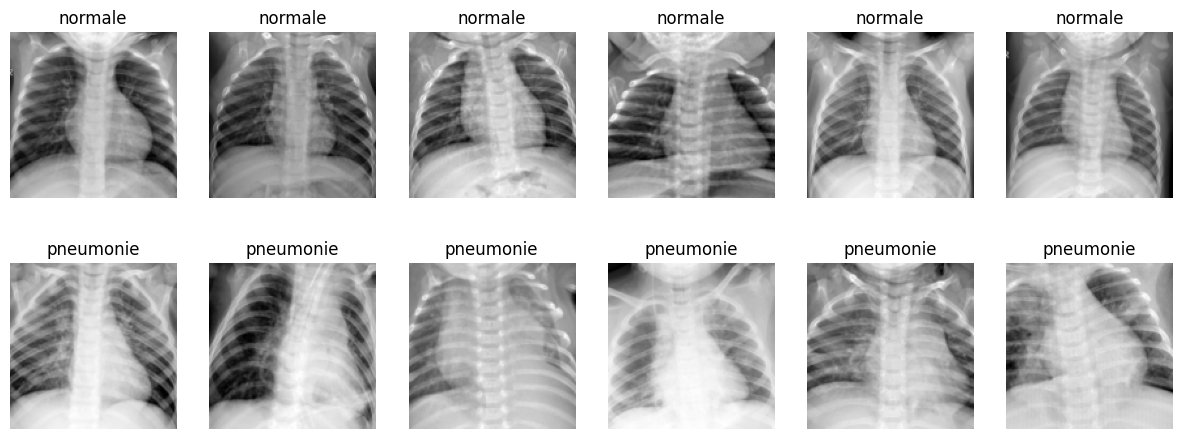

In [5]:
# 6 radiographies de chaque classe, tirées au hasard dans l'entraînement
_, axes = plt.subplots(2, 6, figsize=(15, 5.5))
for label, row in enumerate(axes):
  indexes = numpy.random.choice(numpy.flatnonzero(train_labels == label),
                                size=6,
                                replace=False)
  for ax, index in zip(row, indexes):
    ax.imshow(train_images[index], cmap="gray")
    ax.set_title(LABEL_NAMES[label])
    ax.axis("off")
plt.show()

## Le piège de l'exactitude

Les classes sont déséquilibrées : trois radiographies d'entraînement sur quatre montrent une pneumonie. Voyons ce que donne un « modèle » qui ne regarde même pas l'image et répond toujours « pneumonie ». Deux mesures :

- l'**exactitude** (*accuracy*) : la part de réponses correctes ;
- le **rappel** : la part des pneumonies que le modèle trouve.

In [6]:
# Un « modèle » qui répond toujours « pneumonie » (1), sans regarder l'image
always_pneumonia = numpy.ones_like(test_labels)
accuracy = sklearn.metrics.accuracy_score(test_labels, always_pneumonia)
recall = sklearn.metrics.recall_score(test_labels, always_pneumonia)
print(f"Exactitude sur le test : {accuracy:.1%}")
print(f"Rappel sur le test : {recall:.1%}")

Exactitude sur le test : 62.5%
Rappel sur le test : 100.0%


Sans rien apprendre, ce « modèle » a une exactitude de 62,5 % sur le test (et de 74 % sur l'entraînement), et un rappel parfait : il ne manque aucune pneumonie... parce qu'il déclare tout le monde malade. Une exactitude seule ne veut donc rien dire : il faut la comparer à cette référence, et regarder **quelles** erreurs le modèle fait.

## Le modèle : un réseau pré-entraîné

Entraîner un réseau de neurones à partir de zéro demanderait bien plus que nos 4 708 images. On part donc d'**EfficientNetV2B0**, un réseau déjà entraîné sur ImageNet (1,2 million de photos de la vie courante, aucune radiographie). Ses couches ont appris à repérer des contours, des textures et des formes, ce qui sert aussi pour des radiographies : c'est l'**apprentissage par transfert**.

On remplace sa dernière couche par un seul neurone, qui donne la probabilité de pneumonie, entre 0 et 1. L'entraînement se fait en deux étapes :

1. le réseau pré-entraîné reste figé, seule la nouvelle couche apprend ;
2. on « dégèle » ses dernières couches pour les affiner (*fine-tuning*) sur les radiographies.

Le réseau attend des images en couleur : on recopie le canal gris dans les trois canaux rouge, vert, bleu.

In [7]:
IMAGE_SIZE = 128
BATCH_SIZE = 32


def make_dataset(images: numpy.ndarray,
                 labels: numpy.ndarray,
                 shuffle: bool = False) -> tf.data.Dataset:
  dataset = tf.data.Dataset.from_tensor_slices((images[..., None], labels))
  if shuffle:
    dataset = dataset.shuffle(len(images), seed=42)
  # Le canal gris recopié en 3 canaux (rouge, vert, bleu)
  return (dataset.batch(BATCH_SIZE)
          .map(lambda x, y: (tf.image.grayscale_to_rgb(tf.cast(x, tf.float32)), y))
          .prefetch(tf.data.AUTOTUNE))


train_dataset = make_dataset(train_images, train_labels, shuffle=True)
val_dataset = make_dataset(val_images, val_labels)
test_dataset = make_dataset(test_images, test_labels)

In [8]:
# Le réseau pré-entraîné sur ImageNet, sans sa dernière couche (include_top=False).
# Il normalise lui-même les pixels : il prend des valeurs de 0 à 255.
base_model = keras.applications.EfficientNetV2B0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    pooling="avg")
base_model.trainable = False

inputs = keras.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
# training=False : ses couches de normalisation gardent les statistiques
# apprises sur ImageNet, y compris quand on l'affinera
features = base_model(inputs, training=False)
features = keras.layers.Dropout(0.2)(features)
# Un seul neurone de sortie : la probabilité de pneumonie, entre 0 et 1
outputs = keras.layers.Dense(1, activation="sigmoid")(features)
model = keras.Model(inputs, outputs, name="pneumonia_classifier")

model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
              loss="binary_crossentropy",
              metrics=["accuracy"])
model.summary()

Model: "pneumonia_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 1280)           │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,920,593 (22.59 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

Le résumé montre environ 5,9 millions de paramètres, dont seulement 1 281 entraînables : ceux du nouveau neurone. Tout le reste vient d'ImageNet.

## Entraînement

### Étape 1 : seule la nouvelle couche apprend

Une *époque* est un passage sur toutes les images d'entraînement. Après chacune, Keras affiche l'exactitude (`accuracy`) et la perte (`loss`, l'erreur que l'entraînement fait baisser) sur l'entraînement, puis sur la validation (`val_accuracy`, `val_loss`).

In [9]:
history_head = model.fit(train_dataset, validation_data=val_dataset, epochs=3)

Epoch 1/3
148/148 ━━━━━━━━━━━━━━━━━━━━ 72s 290ms/step - accuracy: 0.8685 - loss: 0.3092 - val_accuracy: 0.9332 - val_loss: 0.1954
Epoch 2/3
148/148 ━━━━━━━━━━━━━━━━━━━━ 23s 16ms/step - accuracy: 0.9244 - loss: 0.1918 - val_accuracy: 0.9485 - val_loss: 0.1602
Epoch 3/3
148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9356 - loss: 0.1649 - val_accuracy: 0.9466 - val_loss: 0.1502


### Étape 2 : affiner les dernières couches du réseau

In [10]:
def plot_history(histories: list) -> None:
  # Les courbes des deux étapes d'entraînement, mises bout à bout
  metrics = {key: sum((history.history[key] for history in histories), [])
             for key in ("accuracy", "val_accuracy", "loss", "val_loss")}
  epochs = range(1, len(metrics["loss"]) + 1)
  _, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
  ax1.plot(epochs, metrics["accuracy"], label="Entraînement")
  ax1.plot(epochs, metrics["val_accuracy"], label="Validation")
  ax1.set_title("Exactitude")
  ax1.set_xlabel("Époque")
  ax1.legend()
  ax2.plot(epochs, metrics["loss"], label="Entraînement")
  ax2.plot(epochs, metrics["val_loss"], label="Validation")
  ax2.set_title("Perte")
  ax2.set_xlabel("Époque")
  ax2.legend()
  plt.show()

Epoch 1/4
148/148 ━━━━━━━━━━━━━━━━━━━━ 56s 197ms/step - accuracy: 0.9465 - loss: 0.1307 - val_accuracy: 0.9695 - val_loss: 0.0889
Epoch 2/4
148/148 ━━━━━━━━━━━━━━━━━━━━ 41s 19ms/step - accuracy: 0.9628 - loss: 0.0953 - val_accuracy: 0.9618 - val_loss: 0.0939
Epoch 3/4
148/148 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.9677 - loss: 0.0774 - val_accuracy: 0.9752 - val_loss: 0.0744
Epoch 4/4
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9760 - loss: 0.0686 - val_accuracy: 0.9771 - val_loss: 0.0542


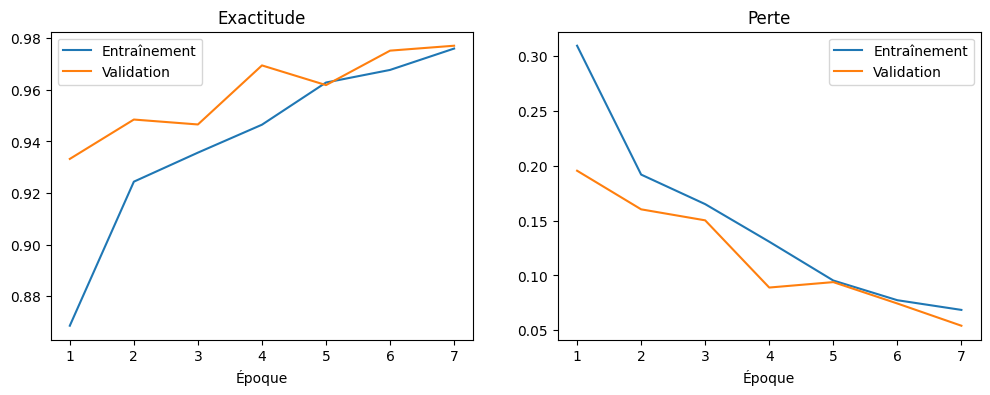

In [11]:
# On dégèle les 40 dernières couches du réseau pré-entraîné, sauf ses couches
# de normalisation (BatchNormalization), qu'il vaut mieux garder figées
base_model.trainable = True
for layer in base_model.layers[:-40]:
  layer.trainable = False
for layer in base_model.layers:
  if isinstance(layer, keras.layers.BatchNormalization):
    layer.trainable = False

# Un taux d'apprentissage 10 fois plus petit, pour ajuster sans tout défaire.
# Recompiler le modèle prend en compte les couches dégelées.
model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-4),
              loss="binary_crossentropy",
              metrics=["accuracy"])

# On s'arrête si la perte de validation ne baisse plus pendant 2 époques, et on
# garde les poids de la meilleure époque
early_stopping = keras.callbacks.EarlyStopping(monitor="val_loss",
                                               patience=2,
                                               restore_best_weights=True)
history_fine_tuning = model.fit(train_dataset,
                                validation_data=val_dataset,
                                epochs=4,
                                callbacks=[early_stopping])

plot_history([history_head, history_fine_tuning])

L'exactitude de validation monte d'environ 93 % après la première époque à environ 97 % après l'affinage.

## Évaluation sur le jeu de test

Pour chaque radiographie, le modèle donne une probabilité de pneumonie. Par défaut, on répond « pneumonie » quand elle dépasse 0,5 : c'est le **seuil de décision**. On mesure, en plus de l'exactitude et du rappel :

- la **précision** : parmi les radiographies que le modèle déclare « pneumonie », la part qui en est vraiment une, c'est-à-dire la fiabilité d'une alerte.

La **matrice de confusion** croise le diagnostic réel (lignes) et la prédiction du modèle (colonnes). En bas à gauche, les **faux négatifs** : des pneumonies manquées. En haut à droite, les **faux positifs** : de fausses alertes sur des enfants sains.

20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 671ms/step
Seuil de décision : 0.50
Exactitude : 88.9%
Précision : 85.1%
Rappel : 99.7%


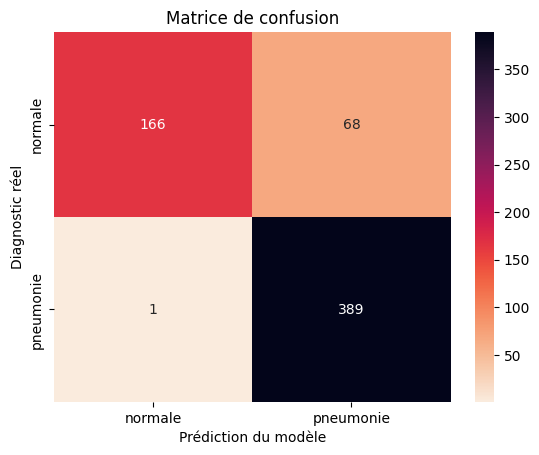

In [12]:
def evaluate(labels: numpy.ndarray,
             probabilities: numpy.ndarray,
             threshold: float = 0.5) -> None:
  predictions = (probabilities >= threshold).astype(int)
  print(f"Seuil de décision : {threshold:.2f}")
  print(f"Exactitude : {sklearn.metrics.accuracy_score(labels, predictions):.1%}")
  print(f"Précision : {sklearn.metrics.precision_score(labels, predictions):.1%}")
  print(f"Rappel : {sklearn.metrics.recall_score(labels, predictions):.1%}")
  confusion_matrix = sklearn.metrics.confusion_matrix(labels, predictions)
  seaborn.heatmap(confusion_matrix,
                  cmap="rocket_r",
                  xticklabels=LABEL_NAMES,
                  yticklabels=LABEL_NAMES,
                  annot=True,
                  fmt="d")
  plt.title("Matrice de confusion")
  plt.xlabel("Prédiction du modèle")
  plt.ylabel("Diagnostic réel")
  plt.show()


test_probabilities = model.predict(test_dataset).ravel()
evaluate(test_labels, test_probabilities)

Lors de notre exécution (les chiffres varient un peu d'une exécution à l'autre) : environ 88 % d'exactitude, contre 62,5 % pour la référence « toujours pneumonie », et un rappel de plus de 99 % (1 pneumonie manquée sur 390). Mais environ 70 des 234 enfants sains sont signalés à tort : une précision d'environ 84 %.

Deux remarques :

- **Quelle erreur est la plus grave ?** En dépistage, une pneumonie manquée (faux négatif) est plus grave qu'une fausse alerte, qu'un radiologue vérifiera. On surveille donc d'abord le rappel. Mais trop de fausses alertes font perdre du temps et la confiance des soignants.
- **La validation était optimiste** : environ 97 % d'exactitude en validation, environ 88 % en test. Les images de test viennent d'un autre lot de patients, avec une autre proportion de pneumonies (62,5 % au lieu de 74 %). Seules des données vraiment nouvelles disent ce que vaut un modèle.

## Choisir le seuil de décision

Le seuil de 0,5 est une convention, pas un choix médical. Le baisser fait trouver plus de pneumonies (meilleur rappel) au prix de plus de fausses alertes (moins bonne précision), le monter fait l'inverse. Le tableau ci-dessous montre ce compromis sur le test.

In [13]:
# Pour plusieurs seuils : combien de pneumonies manquées, combien de fausses alertes ?
rows = []
for threshold in [0.1, 0.3, 0.5, 0.7, 0.9, 0.95]:
  predictions = (test_probabilities >= threshold).astype(int)
  tn, fp, fn, tp = sklearn.metrics.confusion_matrix(test_labels, predictions).ravel()
  rows.append({"Seuil": threshold,
               "Exactitude": sklearn.metrics.accuracy_score(test_labels, predictions),
               "Précision": sklearn.metrics.precision_score(test_labels, predictions),
               "Rappel": sklearn.metrics.recall_score(test_labels, predictions),
               "Pneumonies manquées": fn,
               "Fausses alertes": fp})
pandas.DataFrame(rows).round(3)

,Seuil,Exactitude,Précision,Rappel,Pneumonies manquées,Fausses alertes
0,0.10,0.806,0.763,1.000,0,121
1,0.30,0.857,0.816,0.997,1,88
2,0.50,0.889,0.851,0.997,1,68
3,0.70,0.915,0.887,0.990,4,49
4,0.90,0.942,0.936,0.974,10,26
5,0.95,0.947,0.957,0.959,16,17


Ce tableau sert à comprendre le compromis, pas à choisir : un seuil choisi en regardant le test rendrait le score de test trop flatteur (une fuite de données). Le seuil se fixe sur la **validation**, à partir d'un objectif posé par les médecins, pas par les data scientists. Ici, l'objectif est un rappel d'au moins 98 % : au plus 2 pneumonies manquées sur 100. On prend le plus haut seuil qui l'atteint en validation, puis on vérifie sur le test.

(Un autre levier contre le déséquilibre est de donner plus de poids à la classe rare pendant l'entraînement, avec l'argument `class_weight` de `fit`.)

17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 252ms/step


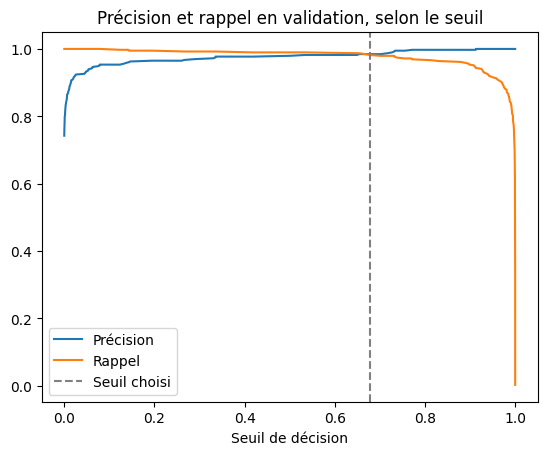

Seuil de décision : 0.68
Exactitude : 90.9%
Précision : 87.9%
Rappel : 99.0%


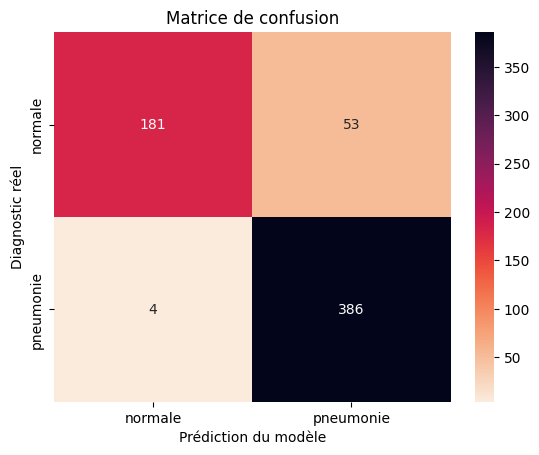

In [14]:
TARGET_RECALL = 0.98

val_probabilities = model.predict(val_dataset).ravel()
precisions, recalls, thresholds = sklearn.metrics.precision_recall_curve(
    val_labels, val_probabilities)
# precisions[i] et recalls[i] correspondent au seuil thresholds[i] (les deux
# tableaux ont un élément de plus, pour un seuil infini)
precisions, recalls = precisions[:-1], recalls[:-1]
chosen_threshold = thresholds[recalls >= TARGET_RECALL].max()

plt.plot(thresholds, precisions, label="Précision")
plt.plot(thresholds, recalls, label="Rappel")
plt.axvline(chosen_threshold, color="gray", linestyle="--", label="Seuil choisi")
plt.title("Précision et rappel en validation, selon le seuil")
plt.xlabel("Seuil de décision")
plt.legend()
plt.show()

evaluate(test_labels, test_probabilities, chosen_threshold)

Lors de notre exécution, le seuil choisi est d'environ 0,74. Sur le test, le rappel reste de 99 % (4 pneumonies manquées sur 390) et les fausses alertes passent d'environ 70 à environ 50 : 3 pneumonies manquées de plus pour une vingtaine de fausses alertes en moins. C'est ce genre d'arbitrage que les médecins doivent trancher.

## Regarder les erreurs

Quelques pneumonies manquées et quelques fausses alertes, avec la probabilité de pneumonie que le modèle leur donne.

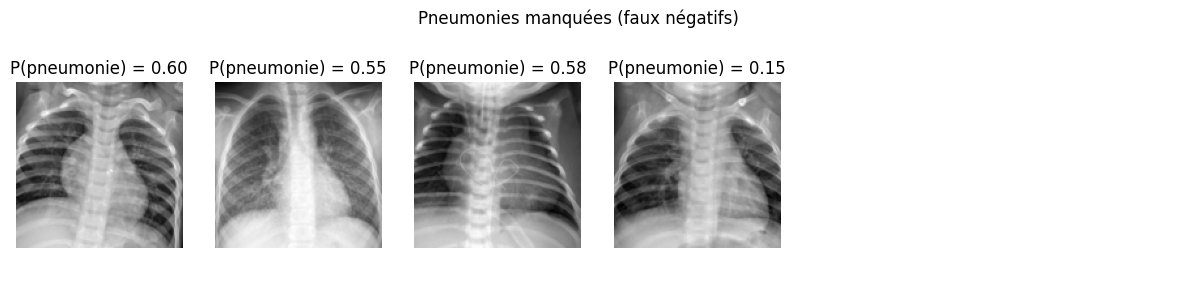

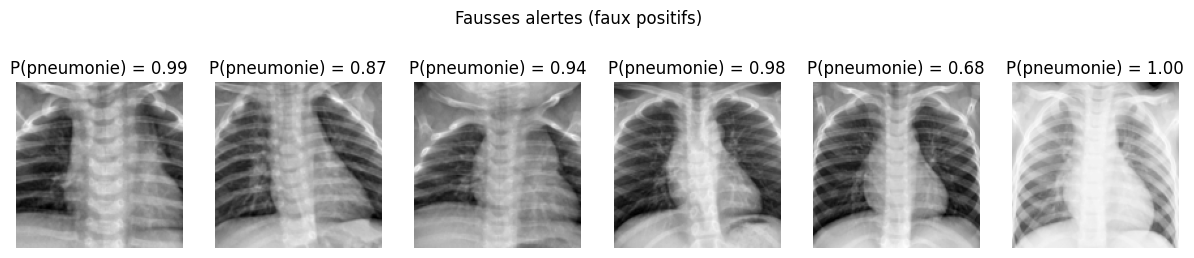

In [15]:
def plot_examples(mask: numpy.ndarray, title: str) -> None:
  indexes = numpy.flatnonzero(mask)[:6]
  if len(indexes) == 0:
    print(f"{title} : aucune")
    return
  _, axes = plt.subplots(1, 6, figsize=(15, 3.2))
  for ax in axes:
    ax.axis("off")
  for ax, index in zip(axes, indexes):
    ax.imshow(test_images[index], cmap="gray")
    ax.set_title(f"P(pneumonie) = {test_probabilities[index]:.2f}")
  plt.suptitle(title)
  plt.show()


test_predictions = (test_probabilities >= chosen_threshold).astype(int)
plot_examples((test_labels == 1) & (test_predictions == 0),
              "Pneumonies manquées (faux négatifs)")
plot_examples((test_labels == 0) & (test_predictions == 1),
              "Fausses alertes (faux positifs)")

## Et si la maladie était rare ?

Dans ce jeu de données, la majorité des radiographies montrent une pneumonie. Dans un dépistage réel, la maladie est bien plus rare. Avec le même modèle, au même seuil, que deviendrait la précision si seulement 5 % des patients étaient malades ?

In [16]:
PATIENTS = 1000
PREVALENCE = 0.05  # 5 % de malades

# Taux mesurés sur le test : part des malades détectés (le rappel) et part des
# enfants sains signalés à tort
recall = (test_predictions[test_labels == 1] == 1).mean()
false_alarm_rate = (test_predictions[test_labels == 0] == 1).mean()

sick = PATIENTS * PREVALENCE
detected = recall * sick
false_alarms = false_alarm_rate * (PATIENTS - sick)
print(f"Sur {PATIENTS} patients, dont {sick:.0f} malades :")
print(f"- {detected:.0f} malades détectés et {false_alarms:.0f} fausses alertes")
print(f"- précision : {detected / (detected + false_alarms):.0%}")

Sur 1000 patients, dont 50 malades :
- 49 malades détectés et 215 fausses alertes
- précision : 19%


Lors de notre exécution : sur 1 000 patients dont 50 malades, 49 sont détectés, au prix d'environ 200 fausses alertes. Seule une alerte sur cinq environ concerne un vrai malade (précision d'environ 20 %), contre près de 9 sur 10 dans ce jeu de données. Le rappel ne dépend pas de la fréquence de la maladie, la précision si : un modèle se valide sur des données qui ressemblent à son usage réel.

## Ce que ce modèle n'est pas

- **Pas un dispositif médical.** Un logiciel qui aide au diagnostic est un dispositif médical (règlement européen 2017/745) : marquage CE, évaluation clinique, surveillance après mise sur le marché. Pour l'AI Act, c'est un système d'IA à haut risque. Ce notebook est une démonstration.
- **Pas un modèle sans biais.** Les radiographies viennent d'enfants de 1 à 5 ans, d'un seul hôpital (Guangzhou, en Chine). Rien ne dit que le modèle fonctionne sur des adultes, dans un autre hôpital, avec un autre appareil : il faudrait le vérifier sur leurs données.
- **Pas un médecin.** Il ne voit qu'une image réduite à 128 × 128 pixels, sans les symptômes ni les antécédents du patient, et ne distingue pas une pneumonie bactérienne d'une virale. Ses étiquettes viennent de médecins, qui peuvent eux-mêmes se tromper.
- **Pas une preuve d'utilité.** Un bon score sur un jeu de test public ne dit pas que les patients seront mieux soignés : cela se mesure par une étude clinique, dans les conditions réelles d'usage.

## À retenir

- Avec des classes déséquilibrées, l'exactitude seule trompe : répondre toujours « pneumonie » donne déjà 62,5 % sur le test. Comparez toujours un modèle à une référence aussi simple.
- La matrice de confusion montre quelles erreurs le modèle fait. Le rappel compte les malades trouvés, la précision dit si l'on peut se fier à une alerte.
- Le seuil de décision est un choix métier (ici médical) : il se fixe sur la validation, à partir d'un objectif, jamais en regardant le test.
- Un réseau pré-entraîné sur des photos s'adapte en quelques minutes à des radiographies : l'apprentissage par transfert permet le deep learning avec quelques milliers d'images.
- Le score de validation était optimiste, et la précision dépend de la fréquence de la maladie : seules des données de l'usage réel disent ce que vaut un modèle.
- Un bon score ne fait ni un dispositif médical, ni un modèle sans biais.